# A/B Test Analysis: Banking Onboarding

This project analyzes an A/B experiment designed to evaluate whether a new onboarding flow improves the conversion rate of users who start registration and successfully complete it.

The experiment compares users assigned to the existing onboarding flow (Control) with users assigned to the new onboarding flow (Treatment).

The main business objective is to determine whether the new onboarding should be rolled out to all users.

## 1. Experiment Design

### Experiment Setup

Users are randomly assigned to one of two groups:

- **Control** — existing onboarding flow
- **Treatment** — new onboarding flow

The experiment includes 100,000 users who started the registration process.

The primary metric is Registration Conversion Rate.

### Hypotheses

**Null hypothesis (H₀):**

There is no difference in registration conversion between the Control and Treatment groups.

$$
H_0: p_{control} = p_{treatment}
$$

**Alternative hypothesis (H₁):**

There is a difference in registration conversion between the two groups.

$$
H_1: p_{control} \neq p_{treatment}
$$

The significance level is set to:

$$
\alpha = 0.05
$$

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

## 2. Data Quality Check

Before analyzing the experiment results, the dataset was checked for common data quality issues, including:

- duplicate users;
- missing values;
- invalid categorical values;
- invalid binary values;
- logically inconsistent registration states;
- incorrect date format.

The dataset passed all quality checks and was considered suitable for further analysis.

In [7]:
df = pd.read_csv("../data/ab_test_data.csv")

df.head()

,user_id,group,registration_started,registration_completed,device,source,experiment_date
0,11,control,1,0,ios,organic,2026-07-01
1,54,treatment,1,0,android,organic,2026-07-01
2,55,treatment,1,0,android,email,2026-07-01
3,235,control,1,0,android,paid_search,2026-07-01
4,273,treatment,1,0,ios,paid_search,2026-07-01


In [8]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 100,000
Columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   user_id                 100000 non-null  int64 
 1   group                   100000 non-null  object
 2   registration_started    100000 non-null  int64 
 3   registration_completed  100000 non-null  int64 
 4   device                  100000 non-null  object
 5   source                  100000 non-null  object
 6   experiment_date         100000 non-null  object
dtypes: int64(3), object(4)
memory usage: 5.3+ MB


In [9]:
df.describe(include="all")

,user_id,group,registration_started,registration_completed,device,source,experiment_date
count,100000.000000,100000,100000.0,100000.000000,100000,100000,100000
unique,NaN,2,NaN,NaN,3,5,30
top,NaN,treatment,NaN,NaN,android,organic,2026-07-19
freq,NaN,50066,NaN,NaN,50071,29941,3493
mean,50000.500000,NaN,1.0,0.085930,NaN,NaN,NaN
std,28867.657797,NaN,0.0,0.280262,NaN,NaN,NaN
min,1.000000,NaN,1.0,0.000000,NaN,NaN,NaN
25%,25000.750000,NaN,1.0,0.000000,NaN,NaN,NaN
50%,50000.500000,NaN,1.0,0.000000,NaN,NaN,NaN
75%,75000.250000,NaN,1.0,0.000000,NaN,NaN,NaN


In [13]:
df["group"].value_counts(normalize=True)

group
treatment    0.50066
control      0.49934
Name: proportion, dtype: float64

In [14]:
df["registration_completed"].value_counts(normalize=True)

registration_completed
0    0.91407
1    0.08593
Name: proportion, dtype: float64

In [15]:
df["user_id"].duplicated().sum()

np.int64(0)

In [16]:
df.isna().sum()

user_id                   0
group                     0
registration_started      0
registration_completed    0
device                    0
source                    0
experiment_date           0
dtype: int64

In [17]:
print("Groups:", df["group"].unique())
print("Devices:", df["device"].unique())
print("Sources:", df["source"].unique())

Groups: ['control' 'treatment']
Devices: ['ios' 'android' 'web']
Sources: ['organic' 'email' 'paid_search' 'social' 'referral']


In [18]:
print("registration_started:", df["registration_started"].unique())
print("registration_completed:", df["registration_completed"].unique())

registration_started: [1]
registration_completed: [0 1]


In [19]:
invalid_records = df[
    (df["registration_completed"] == 1) &
    (df["registration_started"] == 0)
]

len(invalid_records)

0

In [20]:
df["experiment_date"] = pd.to_datetime(df["experiment_date"])

df["experiment_date"].min(), df["experiment_date"].max()

(Timestamp('2026-07-01 00:00:00'), Timestamp('2026-07-30 00:00:00'))

## 3. Exploratory Data Analysis

The exploratory analysis focuses on the distribution of users across experiment groups and key user characteristics.

The main goal is to verify that the Control and Treatment groups are reasonably balanced before comparing their conversion rates.

We examine:

- experiment group sizes;
- device distribution;
- acquisition source distribution;
- overall registration conversion.

In [21]:
group_counts = df["group"].value_counts()

group_counts

group
treatment    50066
control      49934
Name: count, dtype: int64

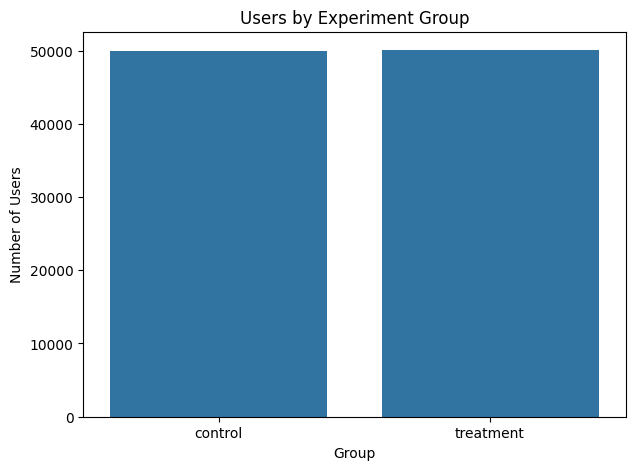

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="group")

plt.title("Users by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Number of Users")

plt.show()

In [23]:
device_distribution = pd.crosstab(
    df["group"],
    df["device"],
    normalize="index"
) * 100

device_distribution.round(2)

device,android,ios,web
group,,,
control,49.96,34.92,15.12
treatment,50.18,34.64,15.18


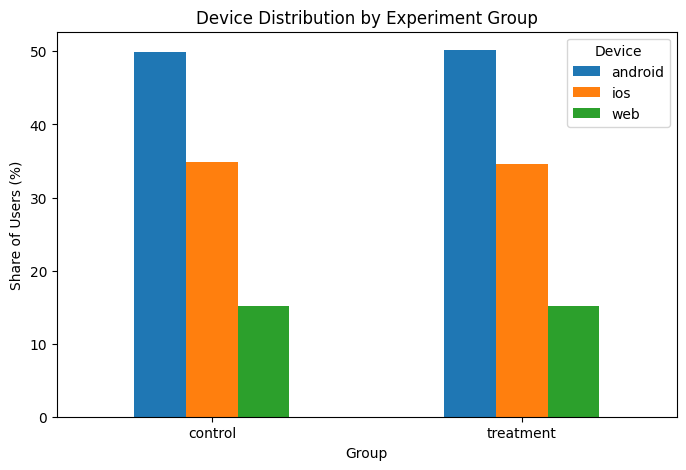

In [24]:
device_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Device Distribution by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Share of Users (%)")
plt.xticks(rotation=0)
plt.legend(title="Device")

plt.show()

In [25]:
source_distribution = pd.crosstab(
    df["group"],
    df["source"],
    normalize="index"
) * 100

source_distribution.round(2)

source,email,organic,paid_search,referral,social
group,,,,,
control,9.99,29.58,24.98,15.27,20.18
treatment,10.05,30.30,24.76,14.79,20.10


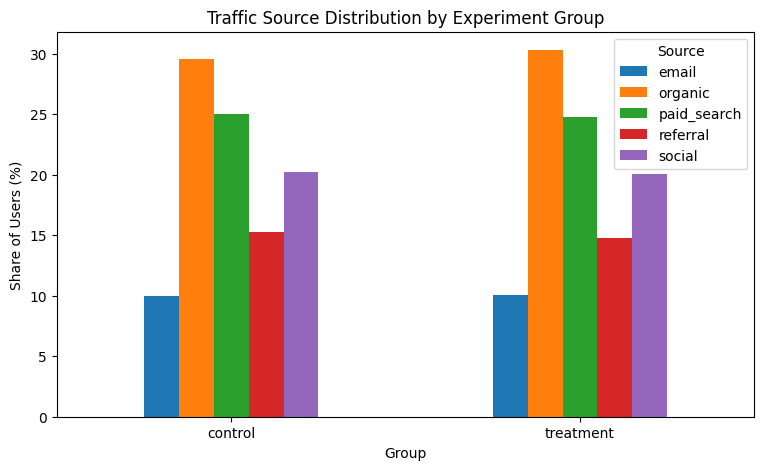

In [26]:
source_distribution.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Traffic Source Distribution by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Share of Users (%)")
plt.xticks(rotation=0)
plt.legend(title="Source")

plt.show()

## 4. Registration Conversion Rate

The primary metric of the experiment is Registration Conversion Rate.

$$
Conversion\ Rate =
\frac{Successful\ Registrations}
{Registration\ Starts}
$$

The metric is calculated separately for the Control and Treatment groups.

This allows us to measure the observed effect of the new onboarding flow before applying statistical testing.

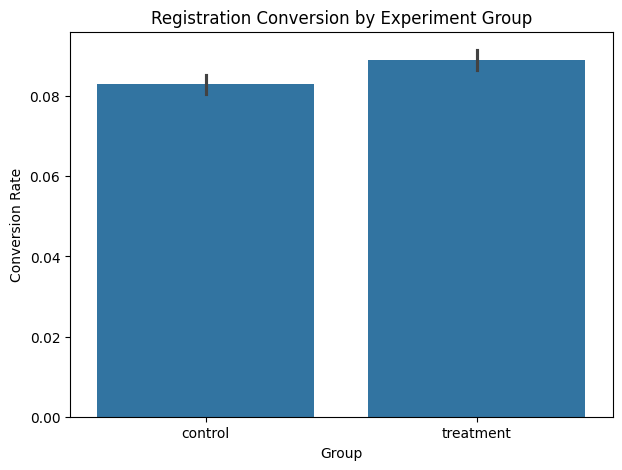

In [45]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="group",
    y="registration_completed"
)

plt.title("Registration Conversion by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")

plt.show()

In [29]:
conversion = (
    df.groupby("group")["registration_completed"]
    .agg(["sum", "count"])
)

conversion["conversion_rate"] = (
    conversion["sum"] / conversion["count"]
)

conversion

,sum,count,conversion_rate
group,,,
control,4141,49934,0.082929
treatment,4452,50066,0.088923


In [30]:
control_rate = conversion.loc["control", "conversion_rate"]
treatment_rate = conversion.loc["treatment", "conversion_rate"]

absolute_uplift = treatment_rate - control_rate
relative_uplift = absolute_uplift / control_rate

print(f"Control conversion: {control_rate:.4%}")
print(f"Treatment conversion: {treatment_rate:.4%}")
print(f"Absolute uplift: {absolute_uplift:.4%}")
print(f"Relative uplift: {relative_uplift:.2%}")

Control conversion: 8.2929%
Treatment conversion: 8.8923%
Absolute uplift: 0.5993%
Relative uplift: 7.23%


## 5. Statistical Significance

To determine whether the observed difference in conversion could be explained by random variation, we perform a two-proportion z-test.

The significance level is:

$$
\alpha = 0.05
$$

Decision rule:

- if **p-value < 0.05**, reject H₀;
- if **p-value ≥ 0.05**, do not reject H₀.

The test evaluates whether the conversion rates of the Control and Treatment groups are statistically different.

In [46]:
control_successes = conversion.loc["control", "sum"]
treatment_successes = conversion.loc["treatment", "sum"]

control_total = conversion.loc["control", "count"]
treatment_total = conversion.loc["treatment", "count"]

successes = np.array([
    treatment_successes,
    control_successes
])

sample_sizes = np.array([
    treatment_total,
    control_total
])

z_stat, p_value = proportions_ztest(
    successes,
    sample_sizes
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Z-statistic: 3.3811
P-value: 0.000722


In [32]:
alpha = 0.05

if p_value < alpha:
    print("Result: statistically significant")
else:
    print("Result: not statistically significant")

Result: statistically significant


## 6. Confidence Interval

In addition to statistical significance, we estimate a 95% confidence interval for the difference in conversion rates between Treatment and Control.

The confidence interval helps quantify the uncertainty around the estimated effect.

If the interval does not include zero, the observed difference is consistent with a statistically significant effect at the 5% level.

In [33]:
ci_low, ci_high = confint_proportions_2indep(
    treatment_successes,
    treatment_total,
    control_successes,
    control_total,
    method="wald"
)

print(f"95% CI for uplift: [{ci_low:.4%}, {ci_high:.4%}]")

95% CI for uplift: [0.2519%, 0.9467%]


In [34]:
results = pd.DataFrame({
    "Metric": [
        "Control Conversion",
        "Treatment Conversion",
        "Absolute Uplift",
        "Relative Uplift",
        "P-value",
        "95% CI Lower",
        "95% CI Upper"
    ],
    "Value": [
        control_rate,
        treatment_rate,
        absolute_uplift,
        relative_uplift,
        p_value,
        ci_low,
        ci_high
    ]
})

results

,Metric,Value
0,Control Conversion,0.082929
1,Treatment Conversion,0.088923
2,Absolute Uplift,0.005993
3,Relative Uplift,0.072268
4,P-value,0.000722
5,95% CI Lower,0.002519
6,95% CI Upper,0.009467


## 7. Business Impact

Statistical significance alone is not sufficient for a product decision.

We translate the observed conversion uplift into an estimated number of additional successful registrations.

For illustration, we assume that 1,000,000 users start registration each month.

This allows us to evaluate the practical impact of the experiment in business terms.

In [35]:
monthly_users = 1_000_000

additional_registrations = monthly_users * absolute_uplift

print(f"Monthly users: {monthly_users:,}")
print(f"Additional successful registrations: {additional_registrations:,.0f}")

Monthly users: 1,000,000
Additional successful registrations: 5,993


In [36]:
additional_registrations_low = monthly_users * ci_low
additional_registrations_high = monthly_users * ci_high

print(
    f"95% CI for additional registrations: "
    f"{additional_registrations_low:,.0f} - "
    f"{additional_registrations_high:,.0f}"
)

95% CI for additional registrations: 2,519 - 9,467


In [37]:
segment_conversion = (
    df.groupby(["group", "device"])["registration_completed"]
    .mean()
    .unstack()
    * 100
)

segment_conversion.round(2)

device,android,ios,web
group,,,
control,7.98,9.43,6.72
treatment,8.51,10.16,7.27


In [38]:
source_conversion = (
    df.groupby(["group", "source"])["registration_completed"]
    .mean()
    .unstack()
    * 100
)

source_conversion.round(2)

source,email,organic,paid_search,referral,social
group,,,,,
control,8.32,8.73,7.61,10.02,7.18
treatment,8.51,9.62,8.19,10.48,7.68


In [39]:
final_results = pd.DataFrame({
    "Metric": [
        "Control Conversion",
        "Treatment Conversion",
        "Absolute Uplift",
        "Relative Uplift",
        "P-value",
        "95% CI Lower",
        "95% CI Upper",
        "Additional Registrations / 1M Users"
    ],
    "Value": [
        f"{control_rate:.2%}",
        f"{treatment_rate:.2%}",
        f"{absolute_uplift:.2%}",
        f"{relative_uplift:.2%}",
        f"{p_value:.6f}",
        f"{ci_low:.2%}",
        f"{ci_high:.2%}",
        f"{additional_registrations:,.0f}"
    ]
})

final_results

,Metric,Value
0,Control Conversion,8.29%
1,Treatment Conversion,8.89%
2,Absolute Uplift,0.60%
3,Relative Uplift,7.23%
4,P-value,0.000722
5,95% CI Lower,0.25%
6,95% CI Upper,0.95%
7,Additional Registrations / 1M Users,"5,993"


## 8. Conversion Rate Comparison

The chart below compares registration conversion between the Control and Treatment groups. Error bars represent the 95% confidence interval for each group's conversion rate.

The Treatment group shows a higher observed conversion rate than the Control group.

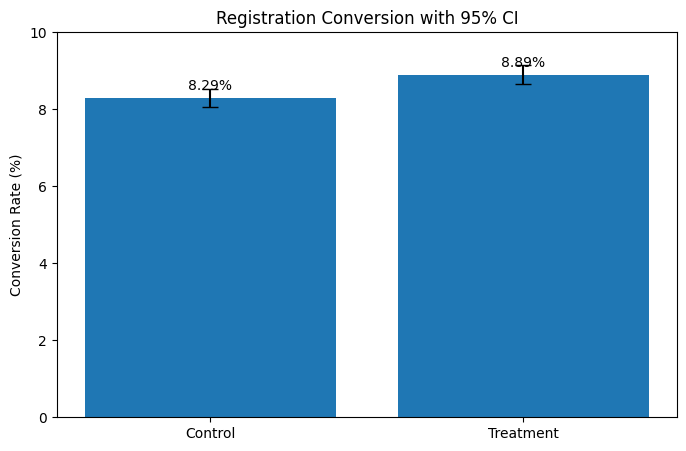

In [44]:
from statsmodels.stats.proportion import proportion_confint

# 95% CI for Control conversion
control_ci_low, control_ci_high = proportion_confint(
    control_successes,
    control_total,
    alpha=0.05,
    method="wilson"
)

# 95% CI for Treatment conversion
treatment_ci_low, treatment_ci_high = proportion_confint(
    treatment_successes,
    treatment_total,
    alpha=0.05,
    method="wilson"
)

rates = [
    control_rate * 100,
    treatment_rate * 100
]

lower_errors = [
    (control_rate - control_ci_low) * 100,
    (treatment_rate - treatment_ci_low) * 100
]

upper_errors = [
    (control_ci_high - control_rate) * 100,
    (treatment_ci_high - treatment_rate) * 100
]

plt.figure(figsize=(8, 5))

plt.bar(
    ["Control", "Treatment"],
    rates,
    yerr=[lower_errors, upper_errors],
    capsize=6
)

plt.ylabel("Conversion Rate (%)")
plt.title("Registration Conversion with 95% CI")

plt.ylim(0, 10)

for i, value in enumerate(rates):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

## 9. Sample Ratio Mismatch Check

Sample Ratio Mismatch (SRM) is a check that verifies whether users were assigned to the experiment groups in the expected proportions.

The experiment was designed with an expected 50/50 split between Control and Treatment.

A chi-square goodness-of-fit test is used to check whether the observed group sizes significantly differ from the expected distribution.

In [40]:
observed_counts = df["group"].value_counts()

observed_control = observed_counts["control"]
observed_treatment = observed_counts["treatment"]

total_users = observed_control + observed_treatment

expected_counts = np.array([
    total_users * 0.5,
    total_users * 0.5
])

observed_counts_array = np.array([
    observed_control,
    observed_treatment
])

chi2_stat, srm_p_value = stats.chisquare(
    observed_counts_array,
    f_exp=expected_counts
)

print(f"Control: {observed_control:,}")
print(f"Treatment: {observed_treatment:,}")
print(f"SRM p-value: {srm_p_value:.6f}")

Control: 49,934
Treatment: 50,066
SRM p-value: 0.676371


In [41]:
if srm_p_value < 0.05:
    print("Potential Sample Ratio Mismatch detected.")
else:
    print("No significant Sample Ratio Mismatch detected.")

No significant Sample Ratio Mismatch detected.


## 10. Final Decision

### Experiment Result

The new onboarding increased registration conversion from **8.29%** in the Control group to **8.89%** in the Treatment group.

This corresponds to:

- **+0.60 percentage points** absolute uplift;
- **+7.23%** relative uplift;
- **p-value = 0.000722**;
- **95% CI: [+0.25 p.p.; +0.95 p.p.]**.

The difference is statistically significant at the 5% significance level.

### Business Impact

If 1,000,000 users start registration each month, the estimated uplift corresponds to approximately **5,993 additional successful registrations per month**.

The 95% confidence interval corresponds to approximately **2,519–9,467 additional registrations per month**.

### Recommendation

**Roll out the new onboarding flow.**

The experiment provides statistically significant evidence that the new onboarding improves registration conversion.

The estimated effect is also practically meaningful, with an expected increase of approximately 6,000 successful registrations per 1 million registration starts.